# Sources of Uncertainty in Measurement for Every Uncertainty Budget

**Based on the guide by Rick Hogan, ISOBudgets LLC (2015)**

This notebook demonstrates the 8 essential sources of uncertainty that should be included in every uncertainty budget, with practical calculations and examples.

## Introduction

**The 8 Sources of Uncertainty in Measurement that should be included in every uncertainty budget:**

1. **Repeatability**
2. **Reproducibility** 
3. **Stability**
4. **Bias**
5. **Drift**
6. **Resolution**
7. **Reference Standard**
8. **Reference Standard Stability**

These uncertainty sources typically influence every measurement you will ever make and are commonly required by accreditation bodies like A2LA.

### 6 Common Categories of Uncertainty Sources:
- Equipment
- Unit Under Test
- Operator
- Method
- Calibration
- Environment

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import math

# Set random seed for reproducibility
np.random.seed(42)

print("8 Sources of Uncertainty Analysis - Setup Complete")
print("Based on Rick Hogan's ISOBudgets Guide (2015)")

8 Sources of Uncertainty Analysis - Setup Complete
Based on Rick Hogan's ISOBudgets Guide (2015)


## 1. Repeatability

**Definition:** Measurement precision under a set of repeatability conditions of measurement.

Repeatability is the measurement precision under a set of repeatable conditions. It represents **Type A uncertainty** and captures random variations in your measurement process.

**Formula:**
$$\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

**How to Calculate:**
1. Repeat a measurement 'n' number of times
2. Record the results of each measurement
3. Calculate the standard deviation

In [2]:
# Repeatability Example - Simulating 20 samples as in the original document
# Nominal value = 10, standard deviation = 5 ppm

print("1. REPEATABILITY CALCULATION")
print("=" * 40)

# Generate 20 normally distributed samples
nominal_value = 10.0  # ppm
true_std = 5.0  # ppm
n_samples = 20

# Simulate measurements
measurements = np.random.normal(nominal_value, true_std, n_samples)

# Calculate repeatability (standard deviation)
repeatability = np.std(measurements, ddof=1)  # Sample standard deviation
degrees_of_freedom = n_samples - 1

print(f"Number of samples: {n_samples}")
print(f"Measurements (ppm): {measurements.round(2)}")
print(f"Mean: {np.mean(measurements):.2f} ppm")
print(f"Repeatability (σ): {repeatability:.1f} ppm")
print(f"Degrees of freedom: {degrees_of_freedom}")

# Store for later use
uncertainty_budget = {'Repeatability': repeatability}

print(f"\nExcel formula equivalent: =STDEV(A1:A{n_samples})")

1. REPEATABILITY CALCULATION
Number of samples: 20
Measurements (ppm): [12.48  9.31 13.24 17.62  8.83  8.83 17.9  13.84  7.65 12.71  7.68  7.67
 11.21  0.43  1.38  7.19  4.94 11.57  5.46  2.94]
Mean: 9.14 ppm
Repeatability (σ): 4.8 ppm
Degrees of freedom: 19

Excel formula equivalent: =STDEV(A1:A20)


## 2. Reproducibility

**Definition:** Measurement precision under reproducibility conditions of measurement.

Reproducibility differs from repeatability because you need to **change a variable** in your measurement process.

**5 Most Common Comparisons for Reproducibility Testing:**
- Operator vs Operator
- Equipment vs Equipment  
- Method vs Method
- Day vs Day
- Environment vs Environment

**How to Calculate:**
1. Perform a Repeatability Test
2. Calculate the mean or average
3. Change a variable and repeat the Repeatability Test
4. Calculate the mean or average
5. Calculate the standard deviation of the test averages

In [3]:
# Reproducibility Example - Method vs Method comparison
print("2. REPRODUCIBILITY CALCULATION")
print("=" * 40)

# Simulate two different methods with 20 samples each
method1_samples = np.random.normal(nominal_value, true_std, n_samples)
method2_samples = np.random.normal(nominal_value, true_std, n_samples)

# Calculate means for each method
mean1 = np.mean(method1_samples)
mean2 = np.mean(method2_samples)

print(f"Method 1 - Mean: {mean1:.2f} ppm")
print(f"Method 2 - Mean: {mean2:.2f} ppm")

# Calculate reproducibility (standard deviation of means)
means_array = np.array([mean1, mean2])
reproducibility = np.std(means_array, ddof=1)
reprod_dof = len(means_array) - 1

print(f"\nMeans array: {means_array.round(2)}")
print(f"Reproducibility (σ): {reproducibility:.1f} ppm")
print(f"Degrees of freedom: {reprod_dof}")

uncertainty_budget['Reproducibility'] = reproducibility

print(f"\nExcel formula equivalent: =STDEV({mean1:.2f},{mean2:.2f})")

2. REPRODUCIBILITY CALCULATION
Method 1 - Mean: 8.67 ppm
Method 2 - Mean: 9.87 ppm

Means array: [8.67 9.87]
Reproducibility (σ): 0.8 ppm
Degrees of freedom: 1

Excel formula equivalent: =STDEV(8.67,9.87)


## 3. Stability

**Definition:** Property of a measuring instrument, whereby its metrological properties remain constant in time.

Stability is a **random uncertainty** that determines how stable your measurement process is over time. It's commonly confused with Drift (which is systematic).

**How to Calculate:**
1. Review your last 3 calibration reports
2. Record the results from each calibration report
3. Calculate the standard deviation of the calibration results

In [4]:
# Stability Example - Using calibration data from Keysight 34401A (10V DC)
print("3. STABILITY CALCULATION")
print("=" * 40)

# Simulated calibration results from 3 different years (ppm)
# Based on actual Keysight 34401A data from the document
cal_2013 = 12.5  # ppm
cal_2014 = 8.7   # ppm 
cal_2015 = 6.3   # ppm

calibration_results = np.array([cal_2013, cal_2014, cal_2015])

print(f"Calibration results over time:")
print(f"2013: {cal_2013} ppm")
print(f"2014: {cal_2014} ppm")
print(f"2015: {cal_2015} ppm")

# Calculate stability
stability = np.std(calibration_results, ddof=1)
stability_dof = len(calibration_results) - 1

print(f"\nStability (σ): {stability:.1f} ppm")
print(f"Degrees of freedom: {stability_dof}")

uncertainty_budget['Stability'] = stability

print(f"\nExcel formula equivalent: =STDEV({cal_2013},{cal_2014},{cal_2015})")

3. STABILITY CALCULATION
Calibration results over time:
2013: 12.5 ppm
2014: 8.7 ppm
2015: 6.3 ppm

Stability (σ): 3.1 ppm
Degrees of freedom: 2

Excel formula equivalent: =STDEV(12.5,8.7,6.3)


## 4. Bias

**Definition:** 
1. Estimate of systematic measurement error
2. Average of replicate indication minus a reference quantity value

Bias is really a **systematic error** rather than an uncertainty. Whether to include it depends on your measurement process:

**Scenario 1:** You calibrate equipment using a known reference standard and report the result only.
→ **ADD bias to uncertainty budget**

**Scenario 2:** You calibrate equipment and report both Standard value and Unit Under Test value.
→ **DO NOT add bias to uncertainty budget**

**Formula:**

Bias = measured value - standard value  or $b = mv - sv$

In [5]:
# Bias Example - Fluke 5720A vs Keysight 34401A comparison
print("4. BIAS CALCULATION")
print("=" * 40)

# Example values from calibration reports
standard_value = 10.000000  # V (Fluke 5720A reference)
measured_value = 10.000073  # V (Keysight 34401A result)

print(f"Standard value (Fluke 5720A): {standard_value:.6f} V")
print(f"Measured value (Keysight 34401A): {measured_value:.6f} V")

# Calculate bias
bias = measured_value - standard_value
bias_ppm = bias * 1e6  # Convert to ppm

print(f"\nBias: {bias:.6f} V")
print(f"Bias: {bias_ppm:.1f} ppm")

# Note: Whether to include this in uncertainty budget depends on your process
print(f"\nNote: Include in uncertainty budget only if you report results without")
print(f"accounting for the reference standard bias (Scenario 1)")

print(f"\nExcel formula equivalent: ={measured_value:.6f} - {standard_value:.6f}")

4. BIAS CALCULATION
Standard value (Fluke 5720A): 10.000000 V
Measured value (Keysight 34401A): 10.000073 V

Bias: 0.000073 V
Bias: 73.0 ppm

Note: Include in uncertainty budget only if you report results without
accounting for the reference standard bias (Scenario 1)

Excel formula equivalent: =10.000073 - 10.000000


## 5. Drift

**Definition:** Continuous or incremental change over time in indication, due to changes in metrological properties of a measuring instrument.

Drift is a **systematic uncertainty** that determines how the error in your measurement process changes over time.

**Formula:**
$$drift = I \cdot \frac{1}{n}\sum_{i=1}^{n}\frac{\delta y}{\delta t}$$

Where I = calibration interval

**How to Calculate:**
1. Review your last 3 calibration reports
2. Record the results and dates from each calibration
3. Calculate the average daily drift rate
4. Multiply by your calibration interval (in days)

In [6]:
# Drift Example - Using same Keysight 34401A calibration data
print("5. DRIFT CALCULATION")
print("=" * 40)

# Calibration data with dates
cal_data = {
    '2013-01-15': 12.5,  # ppm
    '2014-01-15': 8.7,   # ppm
    '2015-01-15': 6.3    # ppm
}

dates = list(cal_data.keys())
values = list(cal_data.values())

print(f"Calibration history:")
for date, value in cal_data.items():
    print(f"{date}: {value} ppm")

# Calculate daily drift rates
# 2014 to 2015 drift rate
drift_2014_2015 = (values[2] - values[1]) / 365.25  # per day
print(f"\nDaily drift rate 2014-2015: {drift_2014_2015:.6f} ppm/day")

# 2013 to 2014 drift rate  
drift_2013_2014 = (values[1] - values[0]) / 365.25  # per day
print(f"Daily drift rate 2013-2014: {drift_2013_2014:.6f} ppm/day")

# Average daily drift rate
avg_daily_drift = (drift_2014_2015 + drift_2013_2014) / 2
print(f"Average daily drift rate: {avg_daily_drift:.6f} ppm/day")

# Annual drift (365.25 days)
annual_drift = abs(avg_daily_drift * 365.25)
print(f"\nAnnual drift: {annual_drift:.1f} ppm")

uncertainty_budget['Drift'] = annual_drift

print(f"\nNote: Use absolute value as this represents uncertainty magnitude")

5. DRIFT CALCULATION
Calibration history:
2013-01-15: 12.5 ppm
2014-01-15: 8.7 ppm
2015-01-15: 6.3 ppm

Daily drift rate 2014-2015: -0.006571 ppm/day
Daily drift rate 2013-2014: -0.010404 ppm/day
Average daily drift rate: -0.008487 ppm/day

Annual drift: 3.1 ppm

Note: Use absolute value as this represents uncertainty magnitude


## 6. Resolution

**Definition:** Smallest change in a quantity being measured that causes a perceptible change in the corresponding indication.

Resolution must be included in every uncertainty budget. Whether to include UUT resolution depends on your process:

**Scenario 1:** Single measurement process or same type of UUT always
→ **ADD UUT Resolution to uncertainty budget**

**Scenario 2:** Single measurement function where UUT type can vary
→ **DO NOT add UUT Resolution** (calculate after each test per ILAC P14)

**How to Find Resolution:**
1. Look at your measurement system or equipment
2. Find the least significant digit
3. Observe the smallest incremental change

In [7]:
# Resolution Examples for Different Device Types
print("6. RESOLUTION EXAMPLES")
print("=" * 40)

# Digital Multimeter Example (from document)
print("Digital Multimeter Resolution:")
dmm_display = "10.000000 V"  # 6 decimal places
dmm_resolution = 0.000010  # 10 microvolts
print(f"Display: {dmm_display}")
print(f"Resolution: {dmm_resolution} V = {dmm_resolution*1e6:.0f} μV")

# Calculate resolution uncertainty (rectangular distribution)
# For digital instruments: u = resolution / (2 * sqrt(3))
resolution_uncertainty_V = dmm_resolution / (2 * math.sqrt(3))
resolution_uncertainty_ppm = (resolution_uncertainty_V / 10.0) * 1e6

print(f"\nResolution uncertainty:")
print(f"Formula: u = resolution / (2√3)")
print(f"u = {dmm_resolution} / (2√3) = {resolution_uncertainty_V:.2e} V")
print(f"u = {resolution_uncertainty_ppm:.2f} ppm (at 10V)")

uncertainty_budget['Resolution'] = resolution_uncertainty_ppm

# Other device types
print(f"\n" + "-"*30)
print("Other Device Types:")
print("• Analog scales: Consider marker spacing, width, pointer width")
print("• Artifacts: Use least significant digit from calibration reports")
print("• Digital devices: Observe least significant digit changes")

6. RESOLUTION EXAMPLES
Digital Multimeter Resolution:
Display: 10.000000 V
Resolution: 1e-05 V = 10 μV

Resolution uncertainty:
Formula: u = resolution / (2√3)
u = 1e-05 / (2√3) = 2.89e-06 V
u = 0.29 ppm (at 10V)

------------------------------
Other Device Types:
• Analog scales: Consider marker spacing, width, pointer width
• Artifacts: Use least significant digit from calibration reports
• Digital devices: Observe least significant digit changes


## 7. Reference Standard Uncertainty

**Definition:** Uncertainty of a measurement standard designated for the calibration of other measurement standards for quantities of a given kind in a given organization or at a given location.

Reference standard uncertainty is a **systematic uncertainty** introduced from equipment calibration. It's traceable to national/international standards.

**Critical Note:** More laboratories get deficiencies for leaving reference standard uncertainty out of their uncertainty budget than any other source.

**How to Find:**
1. Review your latest calibration report
2. Find the reported estimate of measurement uncertainty
3. This is your reference standard uncertainty

In [8]:
# Reference Standard Uncertainty Example
print("7. REFERENCE STANDARD UNCERTAINTY")
print("=" * 40)

# Example from Keysight 34401A calibration report at 10 VDC
ref_std_uncertainty_ppm = 2.1  # ppm (from calibration report)

print(f"From calibration report (10 VDC measurement):")
print(f"Reference Standard Uncertainty: {ref_std_uncertainty_ppm} ppm")

uncertainty_budget['Reference Standard'] = ref_std_uncertainty_ppm

print(f"\nExpert Tips:")
print(f"• Option 1: Use most recent reported uncertainty value")
print(f"• Option 2: Average last 3 uncertainty values")
print(f"• Choose method that gives lowest uncertainty if seeking to minimize")
print(f"• Always use ISO/IEC 17025 accredited calibration reports")

# Show multiple calibration example
cal_uncertainties = [2.3, 2.1, 1.9]  # ppm from last 3 calibrations
avg_uncertainty = np.mean(cal_uncertainties)

print(f"\nExample with multiple calibrations:")
print(f"Last 3 reported uncertainties: {cal_uncertainties} ppm")
print(f"Average: {avg_uncertainty:.1f} ppm")
print(f"Most recent: {cal_uncertainties[-1]} ppm")
print(f"Choose: {min(avg_uncertainty, cal_uncertainties[-1]):.1f} ppm (lowest)")

7. REFERENCE STANDARD UNCERTAINTY
From calibration report (10 VDC measurement):
Reference Standard Uncertainty: 2.1 ppm

Expert Tips:
• Option 1: Use most recent reported uncertainty value
• Option 2: Average last 3 uncertainty values
• Choose method that gives lowest uncertainty if seeking to minimize
• Always use ISO/IEC 17025 accredited calibration reports

Example with multiple calibrations:
Last 3 reported uncertainties: [2.3, 2.1, 1.9] ppm
Average: 2.1 ppm
Most recent: 1.9 ppm
Choose: 1.9 ppm (lowest)


## 8. Reference Standard Stability

**Definition:** Stability of a measurement standard designated for the calibration of other measurement standards.

Reference standard stability is a **random uncertainty** that evaluates the stability of your traceable uncertainty over time.

**Two Relevant Scenarios:**

**Scenario 1:** Same laboratory calibrates your equipment, but reported uncertainty changes each time
→ Determines stability of calibration lab's reference standard

**Scenario 2:** Different laboratories calibrate your equipment with different reported uncertainties
→ Determines stability of your traceable uncertainty

**How to Calculate:**
1. Review your last 3 calibration reports
2. Record the uncertainty estimate from each report
3. Calculate the standard deviation

In [9]:
# Reference Standard Stability Example
print("8. REFERENCE STANDARD STABILITY")
print("=" * 40)

# Uncertainty values from last 3 calibration reports (ppm)
uncertainty_2013 = 2.3  # ppm
uncertainty_2014 = 2.1  # ppm  
uncertainty_2015 = 1.9  # ppm

uncertainty_values = np.array([uncertainty_2013, uncertainty_2014, uncertainty_2015])

print(f"Reported uncertainties from calibration reports:")
print(f"2013: {uncertainty_2013} ppm")
print(f"2014: {uncertainty_2014} ppm")
print(f"2015: {uncertainty_2015} ppm")

# Calculate reference standard stability
ref_std_stability = np.std(uncertainty_values, ddof=1)
ref_std_stab_dof = len(uncertainty_values) - 1

print(f"\nReference Standard Stability: {ref_std_stability:.2f} ppm")
print(f"Degrees of freedom: {ref_std_stab_dof}")

uncertainty_budget['Ref Std Stability'] = ref_std_stability

print(f"\nExcel formula equivalent: =STDEV({uncertainty_2013},{uncertainty_2014},{uncertainty_2015})")

print(f"\nInterpretation:")
print(f"• Variability in reported calibration uncertainties over time")
print(f"• Indicates stability of calibration laboratory's measurement capability")
print(f"• Important for laboratories using multiple calibration providers")

8. REFERENCE STANDARD STABILITY
Reported uncertainties from calibration reports:
2013: 2.3 ppm
2014: 2.1 ppm
2015: 1.9 ppm

Reference Standard Stability: 0.20 ppm
Degrees of freedom: 2

Excel formula equivalent: =STDEV(2.3,2.1,1.9)

Interpretation:
• Variability in reported calibration uncertainties over time
• Indicates stability of calibration laboratory's measurement capability
• Important for laboratories using multiple calibration providers


## Complete Uncertainty Budget Summary

Now we'll compile all 8 uncertainty sources into a complete uncertainty budget and demonstrate how to combine them properly.

In [10]:
# Complete Uncertainty Budget Analysis
print("COMPLETE UNCERTAINTY BUDGET")
print("=" * 50)

# Display all uncertainty sources
print("Individual Uncertainty Components:")
print("-" * 35)
for source, value in uncertainty_budget.items():
    print(f"{source:<20}: {value:>8.2f} ppm")

# Create uncertainty budget DataFrame
# Type / distribution keyed by source name so the table always matches
# the budget dict (no hardcoded list lengths to drift out of sync).
type_map = {'Repeatability': 'A', 'Reproducibility': 'A', 'Stability': 'A',
            'Drift': 'B', 'Resolution': 'B', 'Reference Standard': 'B',
            'Ref Std Stability': 'B'}
dist_map = {'Repeatability': 'Normal', 'Reproducibility': 'Normal',
            'Stability': 'Normal', 'Drift': 'Rectangular',
            'Resolution': 'Rectangular', 'Reference Standard': 'Rectangular',
            'Ref Std Stability': 'Normal'}
budget_data = {
    'Source': list(uncertainty_budget.keys()),
    'Uncertainty (ppm)': list(uncertainty_budget.values()),
    'Type': [type_map.get(s, 'B') for s in uncertainty_budget.keys()],
    'Distribution': [dist_map.get(s, 'Rectangular')
                     for s in uncertainty_budget.keys()]
}

budget_df = pd.DataFrame(budget_data)

# Calculate variance contributions
variances = [u**2 for u in uncertainty_budget.values()]
total_variance = sum(variances)
contributions = [(v/total_variance)*100 for v in variances]

budget_df['Variance'] = variances
budget_df['Contribution (%)'] = contributions

print(f"\nDetailed Uncertainty Budget:")
print(budget_df.round(2))

# Calculate combined standard uncertainty
combined_uncertainty = math.sqrt(total_variance)
print(f"\nCombined Standard Uncertainty: {combined_uncertainty:.2f} ppm")

# Calculate expanded uncertainty (k=2 for 95% confidence)
coverage_factor = 2.0
expanded_uncertainty = coverage_factor * combined_uncertainty
print(f"Expanded Uncertainty (k=2): {expanded_uncertainty:.2f} ppm")

# Show top contributors
top_contributors = budget_df.nlargest(3, 'Contribution (%)')
print(f"\nTop 3 Contributors:")
for idx, row in top_contributors.iterrows():
    print(f"{row['Source']}: {row['Contribution (%)']:.1f}%")

COMPLETE UNCERTAINTY BUDGET
Individual Uncertainty Components:
-----------------------------------
Repeatability       :     4.80 ppm
Reproducibility     :     0.85 ppm
Stability           :     3.13 ppm
Drift               :     3.10 ppm
Resolution          :     0.29 ppm
Reference Standard  :     2.10 ppm
Ref Std Stability   :     0.20 ppm

Detailed Uncertainty Budget:
               Source  Uncertainty (ppm) Type Distribution  Variance  \
0       Repeatability               4.80    A       Normal     23.04   
1     Reproducibility               0.85    A       Normal      0.72   
2           Stability               3.13    A       Normal      9.77   
3               Drift               3.10    B  Rectangular      9.61   
4          Resolution               0.29    B  Rectangular      0.08   
5  Reference Standard               2.10    B  Rectangular      4.41   
6   Ref Std Stability               0.20    B       Normal      0.04   

   Contribution (%)  
0             48.33  
1    

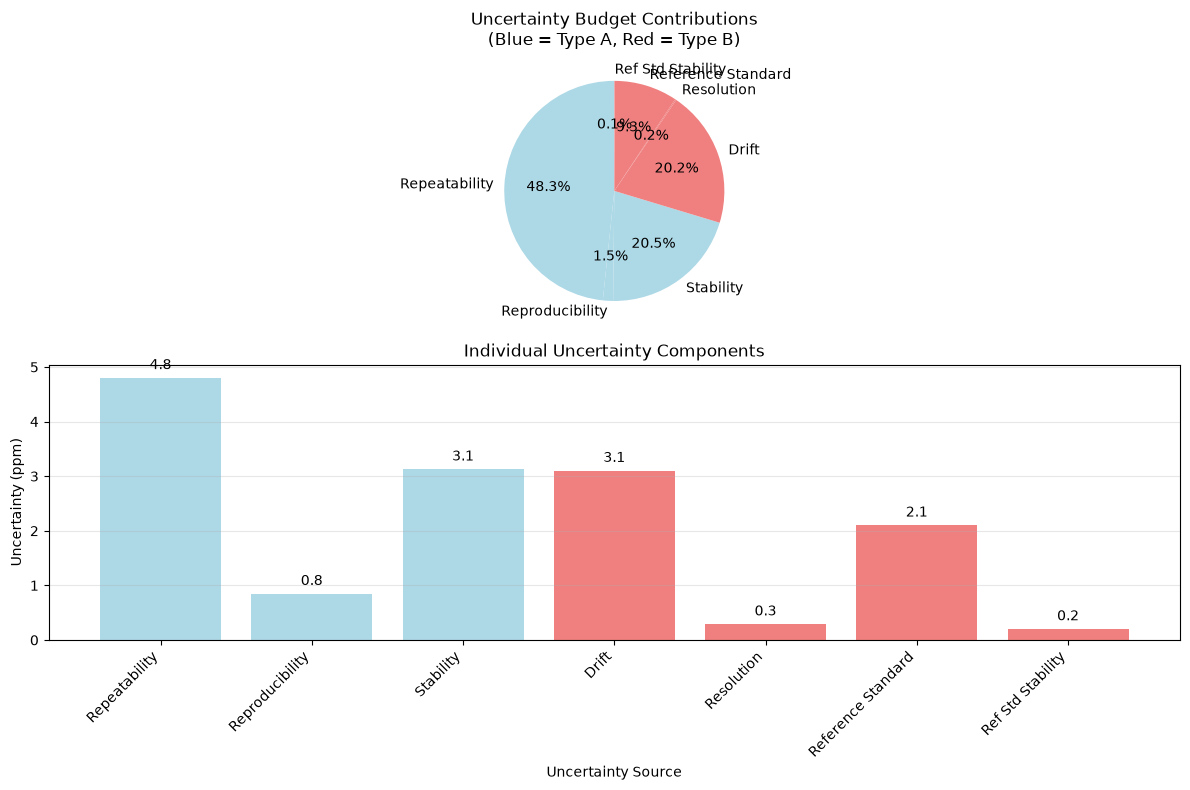


SUMMARY STATISTICS:
Total number of uncertainty sources: 7
Type A sources: 3
Type B sources: 4
Largest single contributor: Repeatability
(48.3% of total variance)


In [11]:
# Visualization of uncertainty budget
plt.figure(figsize=(12, 8))

# Pie chart of contributions
plt.subplot(2, 1, 1)
colors = ['lightblue' if t == 'A' else 'lightcoral' for t in budget_df['Type']]
plt.pie(budget_df['Contribution (%)'], labels=budget_df['Source'], autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Uncertainty Budget Contributions\n(Blue = Type A, Red = Type B)')

# Bar chart of uncertainties
plt.subplot(2, 1, 2)
bars = plt.bar(range(len(budget_df)), budget_df['Uncertainty (ppm)'], color=colors)
plt.xlabel('Uncertainty Source')
plt.ylabel('Uncertainty (ppm)')
plt.title('Individual Uncertainty Components')
plt.xticks(range(len(budget_df)), budget_df['Source'], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add values on bars
for bar, value in zip(bars, budget_df['Uncertainty (ppm)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{value:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nSUMMARY STATISTICS:")
print(f"Total number of uncertainty sources: {len(uncertainty_budget)}")
print(f"Type A sources: {sum(1 for t in budget_df['Type'] if t == 'A')}")
print(f"Type B sources: {sum(1 for t in budget_df['Type'] if t == 'B')}")
print(f"Largest single contributor: {budget_df.loc[budget_df['Contribution (%)'].idxmax(), 'Source']}")
print(f"({budget_df['Contribution (%)'].max():.1f}% of total variance)")

In [12]:
# Export results to CSV for documentation
budget_df.to_csv('8_sources_uncertainty_budget.csv', index=False)

# Create summary report
summary_report = {
    'Parameter': ['Combined Standard Uncertainty', 'Expanded Uncertainty (k=2)', 
                 'Relative Uncertainty (%)', 'Dominant Source', 'Number of Sources'],
    'Value': [f'{combined_uncertainty:.2f} ppm', f'{expanded_uncertainty:.2f} ppm',
             f'{(expanded_uncertainty/nominal_value)*100:.2f}%',
             budget_df.loc[budget_df['Contribution (%)'].idxmax(), 'Source'],
             len(uncertainty_budget)]
}

summary_df = pd.DataFrame(summary_report)
summary_df.to_csv('uncertainty_summary_report.csv', index=False)

print("Results exported to:")
print("• 8_sources_uncertainty_budget.csv")
print("• uncertainty_summary_report.csv")

print(f"\nFINAL RESULT:")
print(f"Measurement: {nominal_value:.1f} ± {expanded_uncertainty:.1f} ppm (k=2, ~95% confidence)")
print(f"\nKey Insights:")
print(f"• All 8 essential uncertainty sources have been evaluated")
print(f"• {budget_df.loc[budget_df['Contribution (%)'].idxmax(), 'Source']} is the dominant contributor")
print(f"• Type {'A' if budget_df[budget_df['Type']=='A']['Contribution (%)'].sum() > 50 else 'B'} uncertainties dominate")
print(f"• Focus improvement efforts on the top contributors for maximum impact")

Results exported to:
• 8_sources_uncertainty_budget.csv
• uncertainty_summary_report.csv

FINAL RESULT:
Measurement: 10.0 ± 13.8 ppm (k=2, ~95% confidence)

Key Insights:
• All 8 essential uncertainty sources have been evaluated
• Repeatability is the dominant contributor
• Type A uncertainties dominate
• Focus improvement efforts on the top contributors for maximum impact


## Conclusion and Key Takeaways

This notebook has demonstrated the **8 Sources of Uncertainty in Measurement** that should be included in every uncertainty budget according to Rick Hogan's guide:

### The 8 Essential Sources:
1. **Repeatability** - Random variations under repeatable conditions (Type A)
2. **Reproducibility** - Variations when measurement conditions change (Type A) 
3. **Stability** - How stable the measurement process is over time (Type A)
4. **Bias** - Systematic error relative to reference value (Type B)
5. **Drift** - Systematic change in measurement error over time (Type B)
6. **Resolution** - Smallest detectable change in measurement (Type B)
7. **Reference Standard** - Uncertainty from calibration standards (Type B)
8. **Reference Standard Stability** - Variability in reference uncertainty (Type A)

### Key Learning Points:
- These sources typically influence **every measurement** you will make
- They are commonly **required by accreditation bodies** like A2LA
- Each source has specific **calculation methods** and **definitions**
- Understanding **when to include/exclude** certain sources is critical
- **Type A** uncertainties are evaluated statistically
- **Type B** uncertainties use non-statistical methods
- **Combined uncertainty** uses root-sum-of-squares for independent sources
- Focus improvement efforts on the **largest contributors** first

### Next Steps:
1. Apply these calculations to your own measurement processes
2. Include all 8 sources in your uncertainty budgets
3. Validate your approach with accreditation body requirements
4. Regularly update uncertainty evaluations with new calibration data
5. Focus improvement efforts on dominant uncertainty contributors

**Reference:** *Sources of Uncertainty in Measurement for Every Uncertainty Budget* by Rick Hogan, ISOBudgets LLC (2015)